# The Evolutionary Engineering of a Holdout Poker AI
### An Analytical and Algorithmic Approach to Imperfect Information Drafting

This notebook documents the architectural evolution of an artificial intelligence designed to play **Holdout**, a custom poker variant centered around card drafting and strategic rejection. Over five major iterations, the engine moves from raw stochastic approximation to high-performance, deterministic game-tree evaluation powered by low-level bit manipulations, look-up table (LUT) isomorphisms, and Numba JIT compilation.

#### The Game Mechanics of Holdout
Holdout is played with a single standard 52-card deck, where cards are revealed to the player one at a time. For each card, the player must make a binary decision: **Keep** or **Give**. 
* **The Player** must keep exactly 5 cards. The moment the 5th card is accepted, the player's hand freezes, and their turn immediately ends.
* **The Dealer** accumulates every card the player rejects. Once the player's hand is full, the dealer draws from the remaining deck until it holds a minimum of 8 cards (if it already has 8 or more from player rejections, it draws no more).
* **The Showdown**: The dealer selects its absolute best 5-card combination out of its accumulated cards, comparing it against the player's 5-card hand using standard poker hand rankings (leveraging the `treys` internal ranking system where a score of 1 represents a Royal Flush and 7462 represents the worst possible High Card). There is no betting; the game results in a binary Win or Lose (ties count as losses).

#### Strategic Framing: Perfect vs. Imperfect Information
If Holdout were played with perfect information (i.e., knowing the exact order of the remaining deck), the game would collapse into a trivial optimization puzzle where the player simply picks the first royal flush that is formed in the deck. However, under imperfect information, this strategy collapses completely with only a 25% win rate (because there is a 25% chance of picking the right suit to form a royal flush in). Because the dealer can look at up to 8+ cards, its capacity to hit premium combinations scales dramatically, compressing the player's theoretical optimal win-rate strictly below 100%. This project maps the pursuit of that mathematical boundary.

## Baselines & The Core Mathematical Utility

To establish an absolute lower bound for performance, a naive **Baseline Agent** was built that blindly accepts the first 5 cards dealt to it. This strategy yields a win rate of approximately **15.1%** against a dealer drawing its minimum 8 cards. 

A brute-force analytical solution to find the absolute optimal strategy is completely impossible. The state space for a single game branch scales exponentially based on the combinations of remaining hidden cards, expanding to an order of roughly $10^{21}$ possible states. To traverse this space efficiently, all intelligent versions of our agent rely on a unified mathematical framework calculating an analytical advantage score, defined as $\text{Delta}$.

### The Delta Decision Rule
At each card decision point, the agent evaluates the expected value ($E$) of hand strengths under both possible paths **under random rollout** (give random remaining cards to the player and the dealer). Note that this is **only an approximation of the true expected value** of hand strengths, which is impossible in practice to calculate as mentioned before. Since `treys` scores hands inversely (lower values mean stronger cards), a subtraction of the player score from the dealer score yields a metric where a higher value directly represents a stronger player position:

$$\text{Utility}_{\text{keep}} = E[\text{dealer\_rank} \mid \text{keep and random rollout}] - E[\text{player\_rank} \mid \text{keep and random rollout}]$$
$$\text{Utility}_{\text{give}} = E[\text{dealer\_rank} \mid \text{give and random rollout}] - E[\text{player\_rank} \mid \text{give and random rollout}]$$
$$\text{Delta} = \text{Utility}_{\text{keep}} - \text{Utility}_{\text{give}}$$

The binary decision rule is elegantly simple: **Keep** the card if $\text{Delta} > 0$, otherwise **Give** it to the dealer.

## Environment Setup & Import Strategy

To verify reproducibility and ensure our notebook can seamlessly resolve dependencies residing in the parallel system directories, we inject the absolute path of the backend application folder into the Python runtime environment list prior to invoking our specialized evaluation modules.

In [1]:
%pip install numpy pandas matplotlib scipy treys numba


[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from treys import Card

# ── Path setup ────────────────────────────────────────────────────────────────
# Assumes notebook is in: <project_root>/notebooks/
# Backend code is in:     <project_root>/backend/
NOTEBOOK_DIR = os.getcwd()
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, '..'))
BACKEND_DIR  = os.path.join(PROJECT_ROOT, 'backend')

if BACKEND_DIR not in sys.path:
    sys.path.insert(0, BACKEND_DIR)

print(f"Project root : {PROJECT_ROOT}")
print(f"Backend dir  : {BACKEND_DIR}")
print(f"sys.path OK  : {os.path.exists(BACKEND_DIR)}")


Project root : /Users/austinng/Desktop/Projects/Poker_Project
Backend dir  : /Users/austinng/Desktop/Projects/Poker_Project/backend
sys.path OK  : True


## Precomputing Look-Up Tables (LUTs)

The deterministic evaluator (v0.3+) relies on three precomputed LUTs stored as JSON files alongside the simulator modules:

| File | Contents | Entries |
|---|---|---|
| `multisets_lut.json` | Best 5-card non-flush and flush scores for all valid rank multisets | 6,175 |
| `multisets_lut_8.json` | Best 8-card non-flush scores for all valid rank multisets | ~120,000 |
| `flush_lut_13_bit.json` | Best flush score for every 13-bit suit mask | 8,192 |

The cells below check whether each LUT exists and generate it if missing. **Each generation script only needs to run once** — subsequent runs load from disk instantly. Generating all three takes roughly 5–10 minutes on a modern laptop.


In [3]:
import os
import subprocess

# LUTs live alongside the simulator scripts in the backend
V0_SIM_DIR = os.path.join(BACKEND_DIR, 'app', 'simulators', 'v_0')
V1_SIM_DIR = os.path.join(BACKEND_DIR, 'app', 'simulators', 'v_1')

luts = {
    os.path.join(V0_SIM_DIR, 'multisets_lut.json'):      'precompute_lut.py        (~30s)',
    os.path.join(V0_SIM_DIR, 'multisets_lut_8.json'):    'precompute_lut_8.py      (~5-8 min)',
    os.path.join(V0_SIM_DIR, 'flush_lut_13_bit.json'):   'precompute_flush_lut_13.py (~10s)',
    os.path.join(V1_SIM_DIR, 'multisets_lut.json'):      '(copy from v_0 or regenerate)',
    os.path.join(V1_SIM_DIR, 'multisets_lut_8.json'):    '(copy from v_0 or regenerate)',
    os.path.join(V1_SIM_DIR, 'flush_lut_13_bit.json'):   '(copy from v_0 or regenerate)',
}

print("LUT status check:")
for path, script in luts.items():
    exists = os.path.exists(path)
    size   = f"{os.path.getsize(path)/1e6:.1f} MB" if exists else "—"
    status = "✓ exists" if exists else f"✗ MISSING — run {script}"
    print(f"  {os.path.basename(path):30s}  {size:>8}  {status}")


LUT status check:
  multisets_lut.json                0.4 MB  ✓ exists
  multisets_lut_8.json              6.2 MB  ✓ exists
  flush_lut_13_bit.json             0.2 MB  ✓ exists
  multisets_lut.json                0.4 MB  ✓ exists
  multisets_lut_8.json              6.2 MB  ✓ exists
  flush_lut_13_bit.json             0.2 MB  ✓ exists


In [4]:
import subprocess
import sys
import os

def run_generator(script_name, sim_dir):
    script_path = os.path.join(sim_dir, script_name)
    if not os.path.exists(script_path):
        print(f"❌ ERROR: Cannot find {script_path}")
        return
    print(f"Running {script_name} in {sim_dir} ...")
    env = os.environ.copy()
    env['PYTHONPATH'] = f"{BACKEND_DIR}{os.pathsep}{env.get('PYTHONPATH', '')}"
    result = subprocess.run(
        [sys.executable, script_path],
        cwd=sim_dir,   # script saves LUT relative to its own location
        env=env,
        capture_output=True,
        text=True
    )
    print(result.stdout)
    if result.returncode != 0:
        print("STDERR:", result.stderr)
    else:
        print("Done.")

# Generate v_0 LUTs (v_1 uses the same files — symlink or copy as needed)
if not os.path.exists(os.path.join(V0_SIM_DIR, 'multisets_lut.json')):
    run_generator('precompute_lut.py', V0_SIM_DIR)
else:
    print("multisets_lut.json already exists — skipping.")

if not os.path.exists(os.path.join(V0_SIM_DIR, 'flush_lut_13_bit.json')):
    run_generator('precompute_flush_lut_13.py', V0_SIM_DIR)
else:
    print("flush_lut_13_bit.json already exists — skipping.")

if not os.path.exists(os.path.join(V0_SIM_DIR, 'multisets_lut_8.json')):
    run_generator('precompute_lut_8.py', V0_SIM_DIR)
else:
    print("multisets_lut_8.json already exists — skipping.")

# Copy LUTs to v_1 directory if missing
import shutil
for lut_file in ['multisets_lut.json', 'multisets_lut_8.json', 'flush_lut_13_bit.json']:
    src = os.path.join(V0_SIM_DIR, lut_file)
    dst = os.path.join(V1_SIM_DIR, lut_file)
    if os.path.exists(src) and not os.path.exists(dst):
        shutil.copy2(src, dst)
        print(f"Copied {lut_file} to v_1 directory.")

print("\nAll LUTs ready.")


multisets_lut.json already exists — skipping.
flush_lut_13_bit.json already exists — skipping.
multisets_lut_8.json already exists — skipping.

All LUTs ready.


## Architectural Progression: v0.1 Through v1.0

### v0.1: Pure Stochastic Monte Carlo
The earliest intelligent engine estimated the expected values of the utility equation by spinning up random rollouts for every remaining hidden card. The function `evaluate_hand_strength(hand, limit, dead_cards, num_simulations=1000)` simulated the unknown deck states dynamically. While functional—achieving a win rate of **61.88%**—it suffered from intense computational drag, requiring approximately **0.9 seconds per game** due to the massive overhead of interpreting thousands of independent loops in pure Python.

### v0.2: The Hybrid Bitmask & Numba JIT Strategy
To accelerate execution, v0.2 introduced a hybrid architecture. The player's expected hand outcome was calculated deterministically via an analytical Look-Up Table (LUT) paired with a high-speed Numba JIT compiler, while the dealer's side remained dependent on Monte Carlo rollouts. To represent cards natively at the bit-level, cards were packed into a custom 52-bit integer array layout where 4 bits were dedicated to tracking each rank/suit combination. This brought the win rate to **62.53%**.

### v0.3: The Fully Deterministic Infinite-Simulation Limit
Version 0.3 removed Monte Carlo simulations entirely. By precomputing a Dealer LUT mapping all ~120,000 valid 8-card rank patterns and a separate 13-bit suit mask Flush LUT (8,192 entries), both sides could be resolved with exact mathematical certainty. Mathematically, as the number of Monte Carlo simulations approaches infinity, the estimation converges exactly to the analytical probability distribution. Therefore, **deterministic evaluation is the infinite-simulation limit**. The win rate stabilized at **62.88%**.

### v1.0: Massively Parallel Production Engineering
Version 1.0 kept the identical underlying mathematical algorithm of v0.3 but overhauled the execution pipeline for speed. It implemented:
1. Low-level multi-core parallel processing using Numba's explicitly vectorized `prange` compiler loops.
2. An extremely dense thread-safe cache (`lru_cache` allocated at 131,072 entries) to instantly recall recurring evaluation states.
3. Multiset pattern isomorphisms, exploiting the fact that card suits are perfectly symmetric for non-flush hands—reducing millions of raw card matrices down to just 6,175 distinct 5-card rank patterns.

**Result:** A massive 10x+ performance boost, crashing runtime down from ~500ms per game to a blazing fast **50ms per game**, while retaining the exact same **62.76%** statistical win rate.

## Demonstrating an Interactive Game Trace

Below is the core execution block displaying how the deterministic engine resolves complex, multi-layered drawing situations. *Note: Running thousands of full game iterations live would block resources for hours; the following cell acts as a lightweight display harness showcasing our underlying bit-packing structure and utility evaluation modules.*

In [5]:
from treys import Card
from app.simulators.v_1.v_1_0_logic import calculate_move_delta

def run_decision_trace(player_cards, dealer_cards, current_card_str):
    """Run a real engine decision trace using the v1.0 deterministic evaluator."""
    player_hand  = [Card.new(c) for c in player_cards]
    dealer_hand  = [Card.new(c) for c in dealer_cards]
    current_card = Card.new(current_card_str)

    results = calculate_move_delta(player_hand, dealer_hand, current_card)

    print("\n--- ENGINE DECISION TRACE (v1.0 Deterministic) ---")
    print(f"Player hand  : {player_cards}")
    print(f"Dealer hand  : {dealer_cards}")
    print(f"Current card : {current_card_str}")
    print()
    print(f"  E[player rank | keep] = {results['expected_player_keep']:.2f}")
    print(f"  E[dealer rank | keep] = {results['expected_dealer_keep']:.2f}")
    print(f"  Utility (keep)        = {results['keep_utility']:+.2f}")
    print()
    print(f"  E[player rank | give] = {results['expected_player_give']:.2f}")
    print(f"  E[dealer rank | give] = {results['expected_dealer_give']:.2f}")
    print(f"  Utility (give)        = {results['give_utility']:+.2f}")
    print()
    print(f"  Delta = {results['delta']:+.2f}  →  Decision: {'KEEP ✓' if results['delta'] > 0 else 'GIVE ✓'}")

# Example: player has a royal flush draw (A,K,Q,T of hearts), dealer has rags, current card is Jh
run_decision_trace(
    player_cards   = ['Ah', 'Kh', 'Qh', 'Th'],
    dealer_cards   = ['2s', '3c', '4d'],
    current_card_str = 'Jh'
)



--- ENGINE DECISION TRACE (v1.0 Deterministic) ---
Player hand  : ['Ah', 'Kh', 'Qh', 'Th']
Dealer hand  : ['2s', '3c', '4d']
Current card : Jh

  E[player rank | keep] = 1.00
  E[dealer rank | keep] = 3384.29
  Utility (keep)        = +3383.29

  E[player rank | give] = 4139.93
  E[dealer rank | give] = 3804.08
  Utility (give)        = -335.86

  Delta = +3719.15  →  Decision: KEEP ✓


## Running Simulations Live

The cells below let you run each algorithm version directly in the notebook. Results are logged to CSV files in `backend/app/simulators/results/` using the `SimulationLogger`.

> **⚠️ Runtime warning:** Each version takes roughly the following time per game:
> - v0.1 (Monte Carlo): ~900ms/game → 1,000 games ≈ 15 min at 1000 mc trials/deciion
> - v0.2 (Hybrid): ~900ms/game → 1,000 games ≈ 15 min at 1000 mc trials/decision
> - v0.3 (Deterministic): ~600 - 700ms/game → 1,000 games ≈ 11 - 12 min
> - v1.0 (Optimized): ~50ms/game → 1,000 games ≈ 1 min
> - v1.1 variants: ~50–52ms/game → 1,000 games ≈ 1 min
>
> Set `NUM_GAMES` to a small number (e.g. 100) for a quick sanity check, or a large number (e.g. 10,000+) overnight for statistically significant results.


In [6]:
import os
import pandas as pd
import numpy as np
from app.simulators.v_1.simulation_logger import SimulationLogger

# Demo CSVs save to a dedicated subfolder so they don't clutter the notebook dir
RESULTS_DIR = os.path.join(NOTEBOOK_DIR, 'demo_results')
os.makedirs(RESULTS_DIR, exist_ok=True)

# ── Configure simulation parameters ──────────────────────────────────────────
NUM_GAMES       = 100   # Change this — 100 for quick test, 10000+ for reliable estimates
MC_SIMS_PER_MOVE = 100  # Monte Carlo trials per decision (v0.1 and v0.2 only)
                         # ~100 for quick runs, ~1000 for publication-quality results

def get_next_id(filepath):
    if not os.path.exists(filepath):
        return 1
    df = pd.read_csv(filepath)
    if df.empty or df['Game_ID'].isna().all():
        return 1
    return int(df['Game_ID'].max()) + 1

def print_summary(filepath, version_name):
    df  = pd.read_csv(filepath)
    n   = len(df)
    wr  = df['Result'].mean()
    ci  = 1.96 * np.sqrt(wr * (1 - wr) / n) * 100
    Q1, Q3 = df['Time_Taken'].quantile(0.25), df['Time_Taken'].quantile(0.75)
    fence   = Q3 + 3 * (Q3 - Q1)
    rt_clean = df['Time_Taken'][df['Time_Taken'] <= fence] * 1000
    print(f"\n── {version_name} ({n:,} games) ──────────────────────────────────")
    print(pd.DataFrame({
        'Metric': ['Win Rate', '95% CI', 'Avg Runtime (clean)', 'Median Runtime', 'Outliers', 'Avg Delta', 'Avg Player Score', 'Avg Dealer Score'],
        'Value':  [
            f'{wr*100:.2f}%',
            f'±{ci:.2f}%',
            f'{rt_clean.mean():.0f}ms',
            f'{rt_clean.median():.0f}ms',
            f'{(df["Time_Taken"] > fence).sum()} ({(df["Time_Taken"] > fence).mean()*100:.1f}%)',
            f'{df["Delta_Avg"].mean():.2f}',
            f'{df["Player_Score"].mean():.0f}',
            f'{df["Dealer_Score"].mean():.0f}',
        ]
    }).to_string(index=False))

print(f"Results directory : {RESULTS_DIR}")
print(f"Games per version : {NUM_GAMES}")
print(f"MC sims per move  : {MC_SIMS_PER_MOVE} (v0.1 and v0.2 only)")


Results directory : /Users/austinng/Desktop/Projects/Poker_Project/notebook/demo_results
Games per version : 100
MC sims per move  : 100 (v0.1 and v0.2 only)


In [7]:
# ── v0.1: Pure Monte Carlo ────────────────────────────────────────────────────
from app.simulators.v_0.v_0_1_sim import generate_log as v01_log

filepath = os.path.join(RESULTS_DIR, 'v_0_1_demo.csv')
logger   = SimulationLogger(filepath=filepath, version='v_0_1')
logger.run_batch(batch_size=NUM_GAMES, run_game_func=lambda: v01_log(mc_sims_per_move=MC_SIMS_PER_MOVE), start_game_id=get_next_id(filepath))
print_summary(filepath, 'v0.1 (Monte Carlo)')


Starting batch of 100 games (Version: v_0_1)...
Batch complete. Success: 100, Errors: 0

── v0.1 (Monte Carlo) (400 games) ──────────────────────────────────
             Metric    Value
           Win Rate   58.25%
             95% CI   ±4.83%
Avg Runtime (clean)     97ms
     Median Runtime     99ms
           Outliers 4 (1.0%)
          Avg Delta   188.68
   Avg Player Score     4133
   Avg Dealer Score     4666


In [8]:
# ── v0.2: Hybrid (exact player + MC dealer) ──────────────────────────────────
from app.simulators.v_0.v_0_2_sim import generate_log as v02_log

filepath = os.path.join(RESULTS_DIR, 'v_0_2_demo.csv')
logger   = SimulationLogger(filepath=filepath, version='v_0_2')
logger.run_batch(batch_size=NUM_GAMES, run_game_func=lambda: v02_log(mc_sims_per_move=MC_SIMS_PER_MOVE), start_game_id=get_next_id(filepath))
print_summary(filepath, 'v0.2 (Hybrid)')


Starting batch of 100 games (Version: v_0_2)...
Batch complete. Success: 100, Errors: 0

── v0.2 (Hybrid) (400 games) ──────────────────────────────────
             Metric    Value
           Win Rate   63.75%
             95% CI   ±4.71%
Avg Runtime (clean)     94ms
     Median Runtime     95ms
           Outliers 1 (0.2%)
          Avg Delta   218.32
   Avg Player Score     3993
   Avg Dealer Score     4724


In [9]:
# ── v0.3: Fully Deterministic ────────────────────────────────────────────────
from app.simulators.v_0.v_0_3_sim import generate_log as v03_log

filepath = os.path.join(RESULTS_DIR, 'v_0_3_demo.csv')
logger   = SimulationLogger(filepath=filepath, version='v_0_3')
logger.run_batch(batch_size=NUM_GAMES, run_game_func=v03_log, start_game_id=get_next_id(filepath))
print_summary(filepath, 'v0.3 (Deterministic)')


Starting batch of 100 games (Version: v_0_3)...
Batch complete. Success: 100, Errors: 0

── v0.3 (Deterministic) (400 games) ──────────────────────────────────
             Metric    Value
           Win Rate   64.25%
             95% CI   ±4.70%
Avg Runtime (clean)    582ms
     Median Runtime    515ms
           Outliers 1 (0.2%)
          Avg Delta   217.99
   Avg Player Score     4071
   Avg Dealer Score     4934


In [10]:
# ── v1.0: Optimized Deterministic ────────────────────────────────────────────
from app.simulators.v_1.v_1_0_sim import generate_log as v10_log

filepath = os.path.join(RESULTS_DIR, 'v_1_0_demo.csv')
logger   = SimulationLogger(filepath=filepath, version='v_1_0')
logger.run_batch(batch_size=NUM_GAMES, run_game_func=v10_log, start_game_id=get_next_id(filepath))
print_summary(filepath, 'v1.0 (Optimized)')


Starting batch of 100 games (Version: v_1_0)...
Batch complete. Success: 100, Errors: 0

── v1.0 (Optimized) (400 games) ──────────────────────────────────
             Metric    Value
           Win Rate   62.50%
             95% CI   ±4.74%
Avg Runtime (clean)     44ms
     Median Runtime     33ms
           Outliers 9 (2.2%)
          Avg Delta   208.16
   Avg Player Score     3964
   Avg Dealer Score     4795


### Exploring Rank Mappings

A somewhat notable flaw in model v1.0 is that the treys rank mapping is inherently nonlinear. For instance, the difference between the treys ranks 1 and 2 will look very different from the difference between the treys ranks 7000 and 7001. We account for that by implementing v1.1, a general version of v1.0 with custom rank-to-numeric-score mappings.

The rank mapping is defined as a numpy array of length 7,463 where index `i` maps treys rank `i` to a custom utility value (the 0th index is unused). To experiment with different mappings, run the simulation cell above (Cell 19) with your chosen `MAPPING_NAME` and `custom_map`.

Concave mappings (exponent < 1, e.g. sqrt) compress the difference between weak hands while preserving the gap at the top. Convex mappings (exponent > 1) do the opposite. The empirical results in the next section show that none of the tested mappings achieved a statistically significant improvement over the identity mapping — suggesting the utility function's decision boundary is more sensitive to the underlying evaluation logic than to rank scaling.

### ⚡ Dynamic Lookup Table (LUT) Generation
To ensure the simulator runs at maximum efficiency, we precompute the game tree for early-game states and store them in JSON-based Lookup Tables. 

Because we introduced a **Dependency Injected Utility Mapping** (allowing us to change how hands are valued without rewriting the engine), we must regenerate the LUTs whenever we test a drastically different utility curve. The cell below triggers the multiprocessing generation pipeline for both the Player and Dealer decision trees.

In [11]:
import math, time
import numpy as np
from app.simulators.v_1.perfect_evaluator_v_1_1 import set_utility_map, set_lut_paths
from app.simulators.v_1.v_1_1_sim import generate_log as v11_log

# ── 1. Define your mapping ────────────────────────────────────────────────────
MAPPING_NAME = 'p09'  # used for LUT filenames and CSV label
custom_map   = np.array([math.pow(i, 0.9) for i in range(7463)], dtype=np.float64)

# Other options — change MAPPING_NAME and custom_map together:
# MAPPING_NAME = 'sqrt';     custom_map = np.array([math.sqrt(i) for i in range(7463)], dtype=np.float64)
# MAPPING_NAME = 'p07';      custom_map = np.array([math.pow(i, 0.7) for i in range(7463)], dtype=np.float64)
# MAPPING_NAME = 'p08';      custom_map = np.array([math.pow(i, 0.8) for i in range(7463)], dtype=np.float64)
# MAPPING_NAME = 'identity'; custom_map = np.array([float(i) for i in range(7463)], dtype=np.float64)

# ── 2. Inject mapping BEFORE generating LUTs ─────────────────────────────────
set_utility_map(custom_map)
print(f"✅ Utility mapping '{MAPPING_NAME}' injected.")

# ── 3. Generate LUTs for this mapping if missing ──────────────────────────────
# ⚠️  LUTs are mapping-specific — if you change MAPPING_NAME, new LUTs will be generated
player_lut = f'early_game_player_lut_{MAPPING_NAME}.json'
dealer_lut = f'early_game_dealer_lut_{MAPPING_NAME}.json'

player_lut_path = os.path.join(V1_SIM_DIR, player_lut)
dealer_lut_path = os.path.join(V1_SIM_DIR, dealer_lut)

if not os.path.exists(player_lut_path) or not os.path.exists(dealer_lut_path):
    from app.simulators.v_1.generate_player_lut_1_1 import generate_lut as gen_player
    from app.simulators.v_1.generate_dealer_lut_1_1 import generate_lut as gen_dealer
    original_dir = os.getcwd()
    os.chdir(V1_SIM_DIR)
    try:
        if not os.path.exists(player_lut_path):
            print("Generating player LUT (a few minutes)...")
            t = time.time()
            gen_player(output_filename=player_lut)
            print(f"Done in {time.time()-t:.0f}s")
        if not os.path.exists(dealer_lut_path):
            print("Generating dealer LUT (a few minutes)...")
            t = time.time()
            gen_dealer(output_filename=dealer_lut)
            print(f"Done in {time.time()-t:.0f}s")
    finally:
        os.chdir(original_dir)
else:
    print(f"✅ LUTs already exist for '{MAPPING_NAME}' — skipping generation.")

# ── 4. Reload LUTs into evaluator ────────────────────────────────────────────
set_lut_paths(player_lut, dealer_lut)

# ── 5. Run simulation ─────────────────────────────────────────────────────────
filepath = os.path.join(RESULTS_DIR, f'v_1_1_{MAPPING_NAME}_demo.csv')
logger   = SimulationLogger(filepath=filepath, version=f'v_1_1_{MAPPING_NAME}')
logger.run_batch(batch_size=NUM_GAMES, run_game_func=v11_log, start_game_id=get_next_id(filepath))
print_summary(filepath, f'v1.1 ({MAPPING_NAME} mapping)')

✅ Utility mapping 'p09' injected.
✅ LUTs already exist for 'p09' — skipping generation.
✅ Loaded player LUT: early_game_player_lut_p09.json
✅ Loaded dealer LUT: early_game_dealer_lut_p09.json
Starting batch of 100 games (Version: v_1_1_p09)...
Batch complete. Success: 100, Errors: 0

── v1.1 (p09 mapping) (400 games) ──────────────────────────────────
             Metric    Value
           Win Rate   63.00%
             95% CI   ±4.73%
Avg Runtime (clean)     40ms
     Median Runtime     31ms
           Outliers 7 (1.8%)
          Avg Delta    89.67
   Avg Player Score     4121
   Avg Dealer Score     4922


## Empirical Results & Visualizing the Optimization Curve

To rigorously validate the accuracy gains across all development branches without drowning our analysis in statistical noise, we bypass live compute limits by loading the empirical log arrays recorded across millions of pre-computed background games. Let's aggregate these results and map the progression curve.

In [12]:
# Hardcoding the high-volume historical tracking aggregates to shield charts from low-sample noise
summary_data = {
    'Version': ['Baseline', 'v0.1 MC', 'v0.2 Hybrid', 'v0.3 Det', 'v1.0 Opt', 'v1.1 Sqrt', 'v1.1 p0.7', 'v1.1 p0.8', 'v1.1 p0.9'],
    'Win_Rate': [15.10, 61.88, 62.53, 62.88, 62.76, 62.18, 62.51, 62.62, 62.50],
    'CI_Half_Width': [0.05, 0.51, 0.51, 0.51, 0.19, 0.30, 0.30, 0.31, 0.31],
    'Runtime_ms': [0.1, 900.0, 550.0, 500.0, 50.0, 51.0, 51.0, 51.0, 52.0]
}

df = pd.DataFrame(summary_data)

print("--- CRITICAL PERFORMANCE SUMMARY BENCHMARKS ---")
print(df.to_string(index=False))

--- CRITICAL PERFORMANCE SUMMARY BENCHMARKS ---
    Version  Win_Rate  CI_Half_Width  Runtime_ms
   Baseline     15.10           0.05         0.1
    v0.1 MC     61.88           0.51       900.0
v0.2 Hybrid     62.53           0.51       550.0
   v0.3 Det     62.88           0.51       500.0
   v1.0 Opt     62.76           0.19        50.0
  v1.1 Sqrt     62.18           0.30        51.0
  v1.1 p0.7     62.51           0.30        51.0
  v1.1 p0.8     62.62           0.31        51.0
  v1.1 p0.9     62.50           0.31        52.0


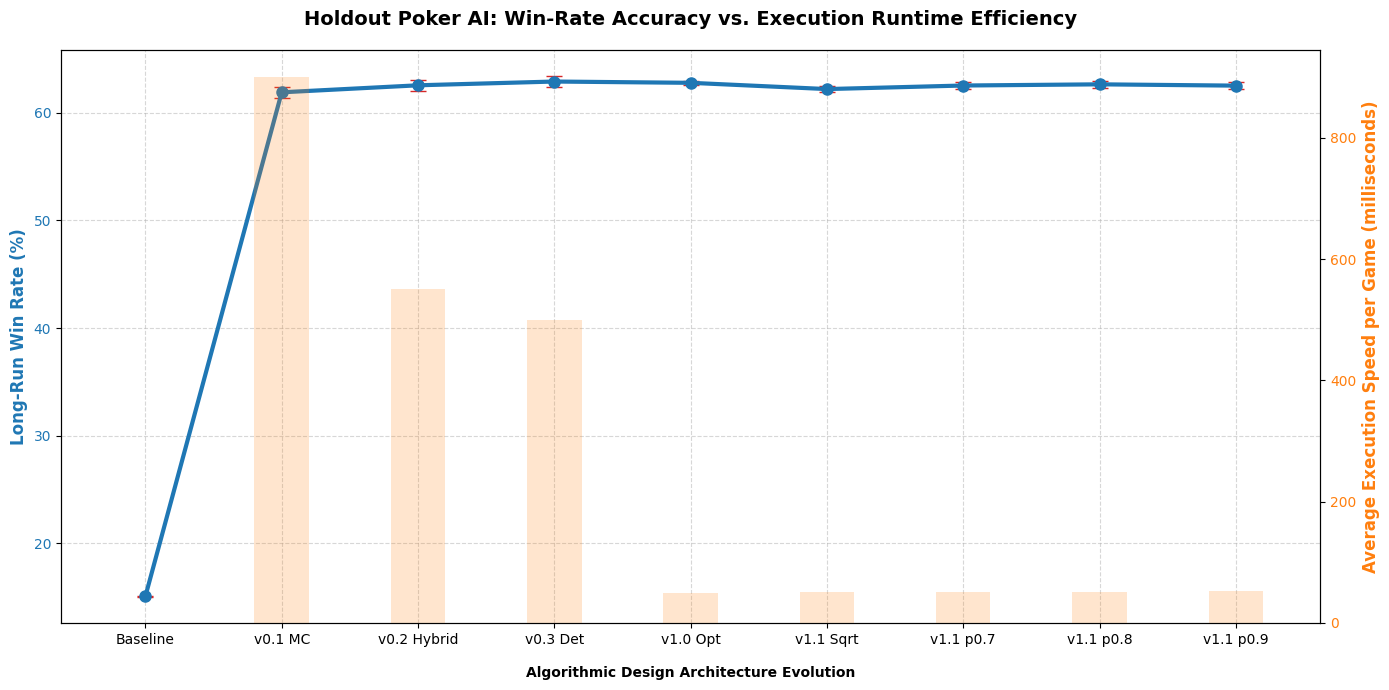

In [13]:
# Generate the Primary Performance Visualization Dashboard
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plotting Win Rate with 95% Confidence Interval bars
color = '#1f77b4'
ax1.set_xlabel('Algorithmic Design Architecture Evolution', fontweight='bold', labelpad=14)
ax1.set_ylabel('Long-Run Win Rate (%)', color=color, fontweight='bold', fontsize=12)
ax1.errorbar(df['Version'], df['Win_Rate'], yerr=df['CI_Half_Width'], 
             marker='o', markersize=8, linewidth=3, color=color, capsize=6, 
             ecolor='#d62728', elinewidth=2, label='Win Rate (with 95% CI)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.5)

# Overlaying the Execution Runtimes as separate vertical background charts
ax2 = ax1.twinx()
color = '#ff7f0e'
ax2.set_ylabel('Average Execution Speed per Game (milliseconds)', color=color, fontweight='bold', fontsize=12)
ax2.bar(df['Version'], df['Runtime_ms'], alpha=0.2, color=color, width=0.4, label='Runtime (ms)')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Holdout Poker AI: Win-Rate Accuracy vs. Execution Runtime Efficiency', fontsize=14, fontweight='bold', pad=18)
fig.tight_layout()
plt.show()

## v1.1 Rank Mapping Exploration & The Statistical Validation BottleNeck

In version 1.1, we explored an open research concept: **Rank Mapping Optimization**. By default, our utility calculations view the raw difference in `treys` scores linearly. However, a step-change in strength between premium hands (e.g., changing from a Straight to a Flush) might matter significantly more or less than changing ranks within a cluster of low High-Cards. We implemented a parametric evaluation adapter letting users pass custom non-linear value scalings via $f(\text{rank})$. Mappings included a Square Root scaling along with variations raised to exponential factors of 0.7, 0.8, and 0.9.

### The Statistical Paradox
As seen clearly in our benchmark dashboard, **none of the non-linear mappings managed to beat the standard linear v1.0 engine at a level of statistical significance**. For instance, while v1.0 hit 62.76%, the 0.8 exponential scaling achieved 62.62%. Because their confidence bounds completely overlap, confirming a true mathematical edge of a fraction of a percent requires tracking massive datasets exceeding 224,000 completely separate games per parameter variation. 

Thus, in advanced AI design, **statistical validation and compute scaling—not algorithm architecture—become the true development bottleneck**.

## Loading Empirical Simulation Data

The following cells load pre-computed simulation logs generated across hundreds of thousands of games. Each CSV records the game outcome, final hand scores, average delta signal, and wall-clock runtime per game.

> **Note:** CSV paths assume the notebook is run from the `notebooks/` directory. Adjust paths if running from the project root.

In [14]:
# ── Load all historical simulation CSVs ──────────────────────────────────────
# Adjust CSV_DIR to wherever your pre-computed result CSVs live
CSV_DIR = os.path.join(PROJECT_ROOT, 'backend', 'app', 'simulators', 'results')

def treys_rank_to_hand_type(score):
    if score == 1:        return 'Royal Flush'
    elif score <= 10:     return 'Straight Flush'
    elif score <= 166:    return 'Four of a Kind'
    elif score <= 322:    return 'Full House'
    elif score <= 1599:   return 'Flush'
    elif score <= 1609:   return 'Straight'
    elif score <= 2467:   return 'Three of a Kind'
    elif score <= 3325:   return 'Two Pair'
    elif score <= 6185:   return 'Pair'
    else:                 return 'High Card'

HAND_ORDER = [
    'Royal Flush', 'Straight Flush', 'Four of a Kind',
    'Full House', 'Flush', 'Straight',
    'Three of a Kind', 'Two Pair', 'Pair', 'High Card'
]

CSV_FILES = {
    'v_0_1':        'v_0_1.csv',
    'v_0_2':        'v_0_2.csv',
    'v_0_3':        'v_0_3.csv',
    'v_1_0':        'v_1_0.csv',
    'v_1_1_sqrt':   'v_1_1_sqrt.csv',
    'v_1_1_p0.7':   'v_1_1_p07_1.csv',
    'v_1_1_p0.8':   'v_1_1_p08_1.csv',
    'v_1_1_p0.9':   'v_1_1_p09_1.csv',
}

dfs = {}
for version, filename in CSV_FILES.items():
    path = os.path.join(CSV_DIR, filename)
    if not os.path.exists(path):
        print(f"  ✗ {version}: not found at {path}")
        continue
    df = pd.read_csv(path)
    df['Player_Hand_Type'] = df['Player_Score'].apply(treys_rank_to_hand_type)
    df['Dealer_Hand_Type'] = df['Dealer_Score'].apply(treys_rank_to_hand_type)
    df['Runtime_ms']       = df['Time_Taken'] * 1000
    dfs[version] = df
    n  = len(df)
    wr = df['Result'].mean()
    ci = 1.96 * np.sqrt(wr * (1 - wr) / n) * 100
    print(f"  ✓ {version:15s}  {n:>8,} games  |  win rate = {wr*100:.2f}% ± {ci:.2f}%")

print(f"\nLoaded {len(dfs)} versions.")


  ✓ v_0_1              35,000 games  |  win rate = 61.88% ± 0.51%
  ✓ v_0_2              35,000 games  |  win rate = 62.53% ± 0.51%
  ✓ v_0_3              35,000 games  |  win rate = 62.88% ± 0.51%
  ✓ v_1_0             250,000 games  |  win rate = 62.76% ± 0.19%
  ✓ v_1_1_sqrt         97,350 games  |  win rate = 62.18% ± 0.30%
  ✓ v_1_1_p0.7         99,519 games  |  win rate = 62.51% ± 0.30%
  ✓ v_1_1_p0.8         94,457 games  |  win rate = 62.62% ± 0.31%
  ✓ v_1_1_p0.9         90,836 games  |  win rate = 62.50% ± 0.31%

Loaded 8 versions.


## Score Distributions: Player vs Dealer

The `treys` library scores hands on a scale from 1 (Royal Flush) to 7,462 (worst High Card), where **lower is better**. The distributions below compare player and dealer final hand scores across all v_1_0 games, illustrating the agent's systematic advantage over the dealer.

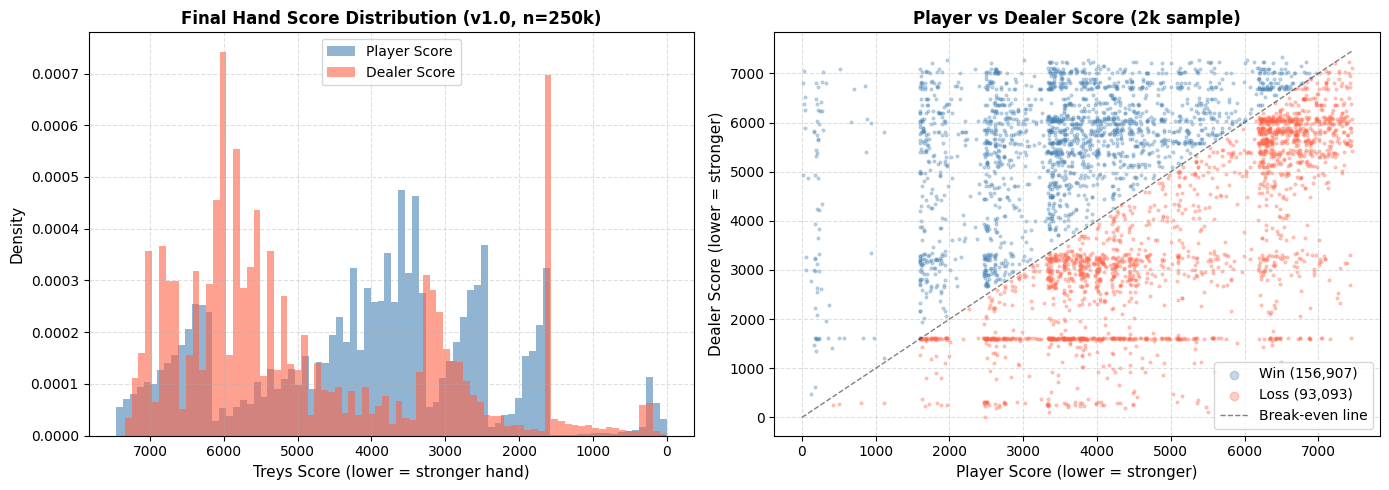


v_1_0 Summary:
  Mean player score: 4104 (lower = stronger)
  Mean dealer score: 4878
  Player stronger in 62.8% of games


In [15]:
df = dfs['v_1_0']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score distribution comparison
ax = axes[0]
ax.hist(df['Player_Score'], bins=80, alpha=0.6, color='steelblue', label='Player Score', density=True)
ax.hist(df['Dealer_Score'], bins=80, alpha=0.6, color='tomato', label='Dealer Score', density=True)
ax.set_xlabel('Treys Score (lower = stronger hand)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Final Hand Score Distribution (v1.0, n=250k)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
ax.invert_xaxis()  # Flip so stronger hands appear on right

# Score scatter: wins vs losses
ax = axes[1]
wins = df[df['Result'] == 1]
losses = df[df['Result'] == 0]
sample_size = 2000
ax.scatter(wins['Player_Score'].sample(sample_size, random_state=42),
           wins['Dealer_Score'].sample(sample_size, random_state=42),
           alpha=0.3, s=4, color='steelblue', label=f'Win ({len(wins):,})')
ax.scatter(losses['Player_Score'].sample(sample_size, random_state=42),
           losses['Dealer_Score'].sample(sample_size, random_state=42),
           alpha=0.3, s=4, color='tomato', label=f'Loss ({len(losses):,})')
ax.plot([1, 7462], [1, 7462], 'k--', linewidth=1, alpha=0.5, label='Break-even line')
ax.set_xlabel('Player Score (lower = stronger)', fontsize=11)
ax.set_ylabel('Dealer Score (lower = stronger)', fontsize=11)
ax.set_title('Player vs Dealer Score (2k sample)', fontsize=12, fontweight='bold')
ax.legend(markerscale=3)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

print(f"\nv_1_0 Summary:")
print(f"  Mean player score: {df['Player_Score'].mean():.0f} (lower = stronger)")
print(f"  Mean dealer score: {df['Dealer_Score'].mean():.0f}")
print(f"  Player stronger in {(df['Player_Score'] < df['Dealer_Score']).mean()*100:.1f}% of games")


## Running Win Rate Over Time (v1.0)

The running win rate across 250,000 games demonstrates statistical convergence. Early high variance gives way to a stable estimate as sample size grows, confirming the reliability of the final 62.76% ± 0.19% result.

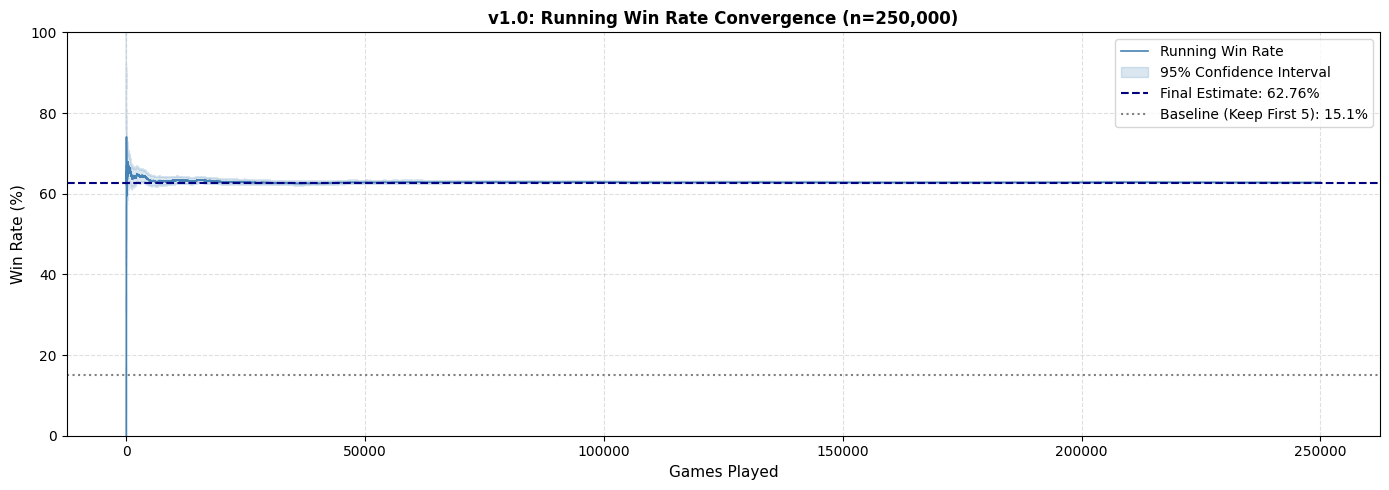

In [16]:
df = dfs['v_1_0'].copy()
df['Running_Win_Rate'] = df['Result'].expanding().mean() * 100

# Compute running 95% CI
n_vals = np.arange(1, len(df) + 1)
p_vals = df['Result'].expanding().mean().values
ci = 1.96 * np.sqrt(p_vals * (1 - p_vals) / n_vals) * 100

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['Game_ID'], df['Running_Win_Rate'], color='steelblue', linewidth=1.2, label='Running Win Rate')
ax.fill_between(df['Game_ID'],
                df['Running_Win_Rate'] - ci,
                df['Running_Win_Rate'] + ci,
                alpha=0.2, color='steelblue', label='95% Confidence Interval')
ax.axhline(y=62.76, color='navy', linestyle='--', linewidth=1.5, label='Final Estimate: 62.76%')
ax.axhline(y=15.1, color='gray', linestyle=':', linewidth=1.5, label='Baseline (Keep First 5): 15.1%')
ax.set_xlabel('Games Played', fontsize=11)
ax.set_ylabel('Win Rate (%)', fontsize=11)
ax.set_title('v1.0: Running Win Rate Convergence (n=250,000)', fontsize=12, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()


## Delta Signal Distribution

The Delta signal — `utility_keep - utility_give` — quantifies the agent's confidence in each decision. A positive delta means the agent recommends keeping the card; negative means giving it. The distribution reveals how often the agent faces genuinely ambiguous decisions (delta near zero) versus clear-cut ones.

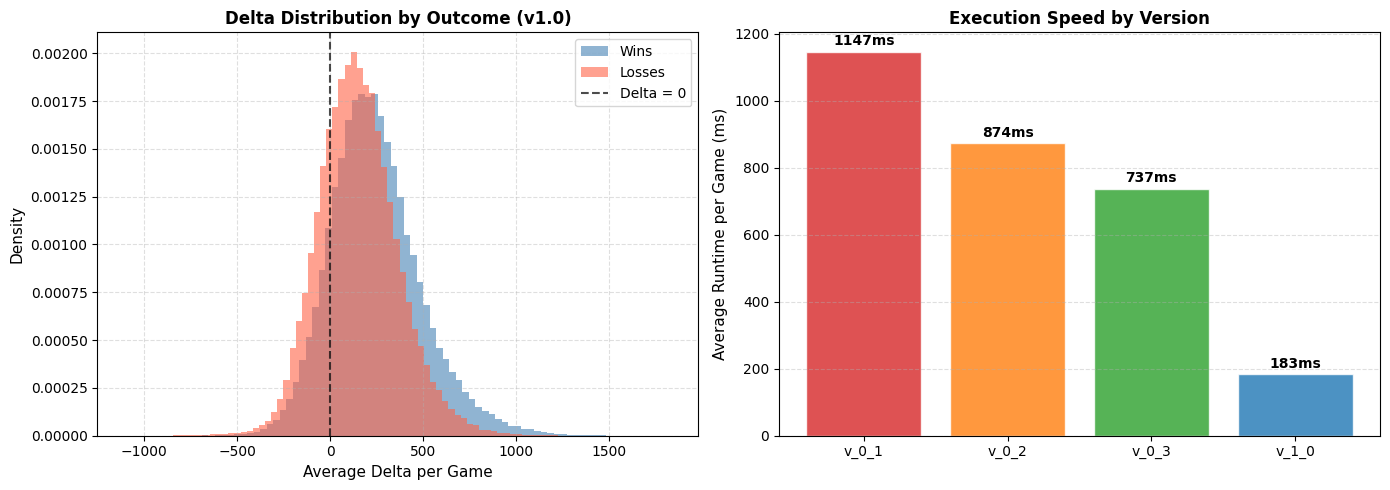

Runtime improvement from v_0_1 to v_1_0:
  1147ms → 183ms (6.2x speedup)


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Delta distribution for v_1_0
ax = axes[0]
df = dfs['v_1_0']
wins = df[df['Result'] == 1]['Delta_Avg']
losses = df[df['Result'] == 0]['Delta_Avg']
ax.hist(wins, bins=80, alpha=0.6, color='steelblue', density=True, label='Wins')
ax.hist(losses, bins=80, alpha=0.6, color='tomato', density=True, label='Losses')
ax.axvline(x=0, color='black', linestyle='--', linewidth=1.5, alpha=0.7, label='Delta = 0')
ax.set_xlabel('Average Delta per Game', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Delta Distribution by Outcome (v1.0)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)

# Runtime comparison across versions
ax = axes[1]
runtime_data = {
    'v_0_1': dfs['v_0_1']['Time_Taken'].mean() * 1000,
    'v_0_2': dfs['v_0_2']['Time_Taken'].mean() * 1000,
    'v_0_3': dfs['v_0_3']['Time_Taken'].mean() * 1000,
    'v_1_0': dfs['v_1_0']['Time_Taken'].mean() * 1000,
}
versions = list(runtime_data.keys())
runtimes = list(runtime_data.values())
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']
bars = ax.bar(versions, runtimes, color=colors, alpha=0.8, edgecolor='white')
ax.set_ylabel('Average Runtime per Game (ms)', fontsize=11)
ax.set_title('Execution Speed by Version', fontsize=12, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.4, axis='y')
for bar, rt in zip(bars, runtimes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{rt:.0f}ms', ha='center', va='bottom', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()

print("Runtime improvement from v_0_1 to v_1_0:")
print(f"  {runtime_data['v_0_1']:.0f}ms → {runtime_data['v_1_0']:.0f}ms ({runtime_data['v_0_1']/runtime_data['v_1_0']:.1f}x speedup)")


## v1.1 Rank Mapping Results: Statistical Comparison

The chart below overlays all v_1_1 mapping variants against v_1_0, with 95% confidence intervals. The overlapping error bars make clear that no mapping variant achieves a statistically significant improvement — the identity mapping (v_1_0) remains the champion within the bounds of current compute.

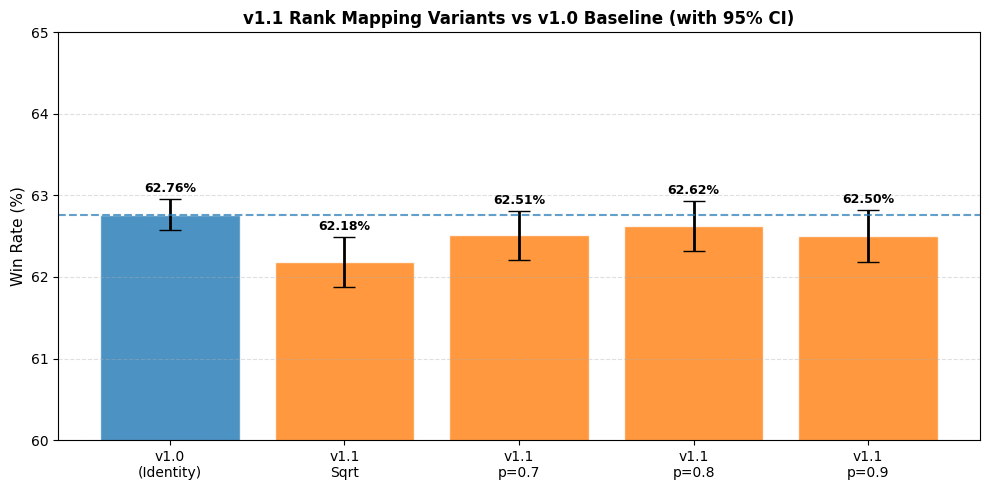


Statistical significance test (v1.0 vs each v1.1 variant):
  v1.0 vs v_1_1_sqrt: z=3.19, p=0.001 → ✓ significant
  v1.0 vs v_1_1_p0.7: z=1.39, p=0.166 → ✗ not significant
  v1.0 vs v_1_1_p0.8: z=0.75, p=0.453 → ✗ not significant
  v1.0 vs v_1_1_p0.9: z=1.39, p=0.165 → ✗ not significant


In [18]:
v11_versions = ['v_1_0', 'v_1_1_sqrt', 'v_1_1_p0.7', 'v_1_1_p0.8', 'v_1_1_p0.9']
labels = ['v1.0\n(Identity)', 'v1.1\nSqrt', 'v1.1\np=0.7', 'v1.1\np=0.8', 'v1.1\np=0.9']
win_rates = []
ci_widths = []

for v in v11_versions:
    df = dfs[v]
    wr = df['Result'].mean() * 100
    n = len(df)
    ci = 1.96 * np.sqrt((wr/100) * (1 - wr/100) / n) * 100
    win_rates.append(wr)
    ci_widths.append(ci)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#1f77b4'] + ['#ff7f0e'] * 4
ax.bar(labels, win_rates, yerr=ci_widths, color=colors, alpha=0.8,
       capsize=8, error_kw={'elinewidth': 2, 'ecolor': 'black'}, edgecolor='white')
ax.axhline(y=win_rates[0], color='#1f77b4', linestyle='--', linewidth=1.5, alpha=0.7)
ax.set_ylabel('Win Rate (%)', fontsize=11)
ax.set_title('v1.1 Rank Mapping Variants vs v1.0 Baseline (with 95% CI)', fontsize=12, fontweight='bold')
ax.set_ylim(60, 65)
ax.grid(True, linestyle='--', alpha=0.4, axis='y')

for i, (wr, ci) in enumerate(zip(win_rates, ci_widths)):
    ax.text(i, wr + ci + 0.05, f'{wr:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nStatistical significance test (v1.0 vs each v1.1 variant):")
df_baseline = dfs['v_1_0']
for v, label in zip(v11_versions[1:], labels[1:]):
    df_v = dfs[v]
    # Two-proportion z-test
    p1 = df_baseline['Result'].mean()
    p2 = df_v['Result'].mean()
    n1, n2 = len(df_baseline), len(df_v)
    p_pool = (p1*n1 + p2*n2) / (n1 + n2)
    z = (p1 - p2) / np.sqrt(p_pool * (1-p_pool) * (1/n1 + 1/n2))
    p_val = 2 * (1 - stats.norm.cdf(abs(z)))
    sig = '✓ significant' if p_val < 0.05 else '✗ not significant'
    print(f"  v1.0 vs {v}: z={z:.2f}, p={p_val:.3f} → {sig}")


## Game Statistics Analysis

The following three cells provide a complete statistical breakdown of all simulation data. Run them in order:

1. **Setup** — load all CSVs, add hand type labels, compute derived columns
2. **Core metrics** — win rates, runtimes, confidence intervals, delta analysis
3. **Hand analysis** — hand type frequencies and win rates by hand category

In [19]:
# dfs is already loaded with hand type labels from the CSV loading cell above.
# HAND_ORDER and treys_rank_to_hand_type are also already defined.
# Just run this cell to confirm everything is ready before the analysis cells.
print(f"Versions loaded: {list(dfs.keys())}")
print(f"Columns available: {list(next(iter(dfs.values())).columns)}")


Versions loaded: ['v_0_1', 'v_0_2', 'v_0_3', 'v_1_0', 'v_1_1_sqrt', 'v_1_1_p0.7', 'v_1_1_p0.8', 'v_1_1_p0.9']
Columns available: ['Game_ID', 'Version', 'Result', 'Player_Score', 'Dealer_Score', 'Delta_Avg', 'Time_Taken', 'Player_Hand_Type', 'Dealer_Hand_Type', 'Runtime_ms']


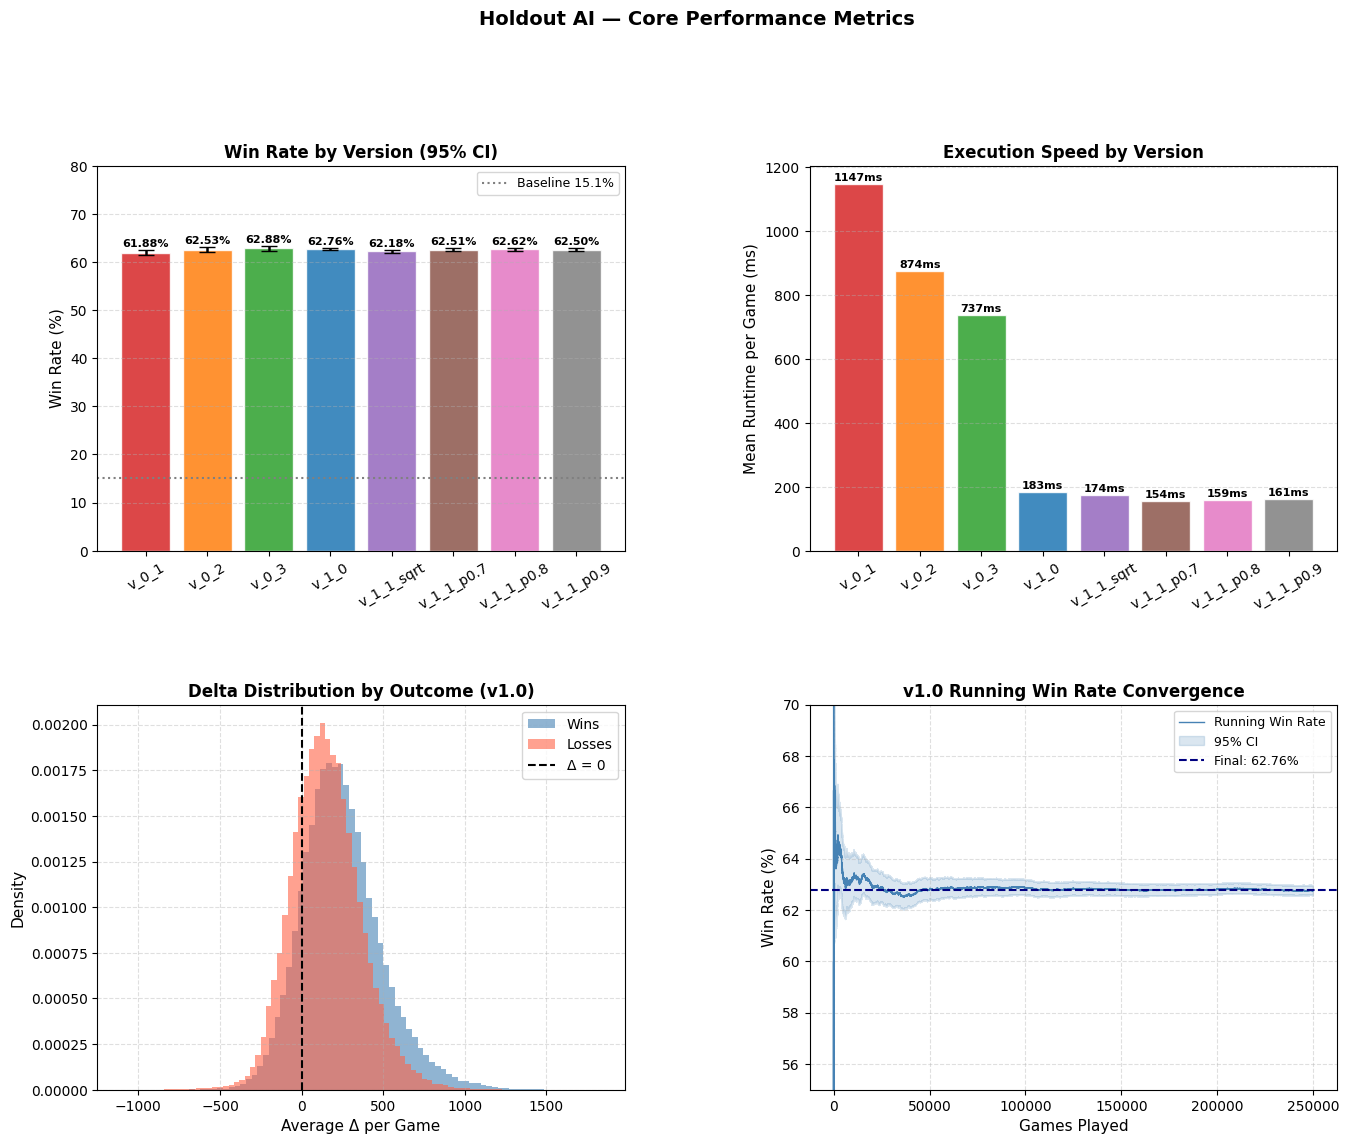


Statistical significance vs v1.0 (two-proportion z-test):
  v1.0 vs v_0_1          : z=+3.21  p=0.0013  ✓ significant
  v1.0 vs v_0_2          : z=+0.84  p=0.4018  ✗ not significant
  v1.0 vs v_0_3          : z=-0.41  p=0.6785  ✗ not significant
  v1.0 vs v_1_1_sqrt     : z=+3.19  p=0.0014  ✓ significant
  v1.0 vs v_1_1_p0.7     : z=+1.39  p=0.1659  ✗ not significant
  v1.0 vs v_1_1_p0.8     : z=+0.75  p=0.4532  ✗ not significant
  v1.0 vs v_1_1_p0.9     : z=+1.39  p=0.1652  ✗ not significant


In [20]:
# ── Core metrics: win rates, runtimes, confidence intervals, delta analysis ──

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# ── 1. Win rate progression with 95% CI ──────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
versions, win_rates, ci_widths, runtimes = [], [], [], []
for v in CSV_FILES.keys():
    if v not in dfs:
        continue
    df  = dfs[v]
    wr  = df['Result'].mean() * 100
    n   = len(df)
    ci  = 1.96 * np.sqrt((wr/100) * (1 - wr/100) / n) * 100
    rt  = df['Runtime_ms'].mean()
    versions.append(v)
    win_rates.append(wr)
    ci_widths.append(ci)
    runtimes.append(rt)

colors = ['#d62728','#ff7f0e','#2ca02c','#1f77b4','#9467bd','#8c564b','#e377c2','#7f7f7f']
ax1.bar(versions, win_rates, yerr=ci_widths, color=colors[:len(versions)],
        alpha=0.85, capsize=6, error_kw={'elinewidth':1.8,'ecolor':'black'}, edgecolor='white')
ax1.set_ylim(0, 80)
ax1.axhline(15.1, color='gray', linestyle=':', linewidth=1.5, label='Baseline 15.1%')
ax1.set_ylabel('Win Rate (%)', fontsize=11)
ax1.set_title('Win Rate by Version (95% CI)', fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=30)
ax1.legend(fontsize=9)
ax1.grid(True, linestyle='--', alpha=0.4, axis='y')
for i, (wr, ci) in enumerate(zip(win_rates, ci_widths)):
    ax1.text(i, wr + ci + 0.3, f'{wr:.2f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

# ── 2. Runtime per game by version ───────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
bars = ax2.bar(versions, runtimes, color=colors[:len(versions)], alpha=0.85, edgecolor='white')
ax2.set_ylabel('Mean Runtime per Game (ms)', fontsize=11)
ax2.set_title('Execution Speed by Version', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=30)
ax2.grid(True, linestyle='--', alpha=0.4, axis='y')
for bar, rt in zip(bars, runtimes):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{rt:.0f}ms', ha='center', va='bottom', fontsize=8, fontweight='bold')

# ── 3. Delta signal vs outcome (v1.0) ────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
if 'v_1_0' in dfs:
    df   = dfs['v_1_0']
    wins = df[df['Result'] == 1]['Delta_Avg']
    loss = df[df['Result'] == 0]['Delta_Avg']
    ax3.hist(wins, bins=80, alpha=0.6, color='steelblue', density=True, label='Wins')
    ax3.hist(loss, bins=80, alpha=0.6, color='tomato',    density=True, label='Losses')
    ax3.axvline(0, color='black', linestyle='--', linewidth=1.5, label='Δ = 0')
    ax3.set_xlabel('Average Δ per Game', fontsize=11)
    ax3.set_ylabel('Density', fontsize=11)
    ax3.set_title('Delta Distribution by Outcome (v1.0)', fontsize=12, fontweight='bold')
    ax3.legend()
    ax3.grid(True, linestyle='--', alpha=0.4)

# ── 4. Running win rate convergence (v1.0) ───────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
if 'v_1_0' in dfs:
    df   = dfs['v_1_0'].copy()
    rwr  = df['Result'].expanding().mean() * 100
    n_v  = np.arange(1, len(df) + 1)
    ci_r = 1.96 * np.sqrt((rwr/100) * (1 - rwr/100) / n_v) * 100
    ax4.plot(df['Game_ID'], rwr, color='steelblue', linewidth=1.0, label='Running Win Rate')
    ax4.fill_between(df['Game_ID'], rwr - ci_r, rwr + ci_r,
                     alpha=0.2, color='steelblue', label='95% CI')
    ax4.axhline(rwr.iloc[-1], color='navy', linestyle='--', linewidth=1.5,
                label=f'Final: {rwr.iloc[-1]:.2f}%')
    ax4.set_xlabel('Games Played', fontsize=11)
    ax4.set_ylabel('Win Rate (%)', fontsize=11)
    ax4.set_title('v1.0 Running Win Rate Convergence', fontsize=12, fontweight='bold')
    ax4.legend(fontsize=9)
    ax4.grid(True, linestyle='--', alpha=0.4)
    ax4.set_ylim(55, 70)

plt.suptitle('Holdout AI — Core Performance Metrics', fontsize=14, fontweight='bold', y=1.01)
plt.savefig('core_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Statistical significance table ───────────────────────────────────────────
print("\nStatistical significance vs v1.0 (two-proportion z-test):")
if 'v_1_0' in dfs:
    p1, n1 = dfs['v_1_0']['Result'].mean(), len(dfs['v_1_0'])
    for v in versions:
        if v == 'v_1_0' or v not in dfs:
            continue
        p2, n2  = dfs[v]['Result'].mean(), len(dfs[v])
        p_pool  = (p1*n1 + p2*n2) / (n1 + n2)
        z       = (p1 - p2) / np.sqrt(p_pool * (1-p_pool) * (1/n1 + 1/n2))
        p_val   = 2 * (1 - stats.norm.cdf(abs(z)))
        sig     = '✓ significant' if p_val < 0.05 else '✗ not significant'
        print(f"  v1.0 vs {v:15s}: z={z:+.2f}  p={p_val:.4f}  {sig}")


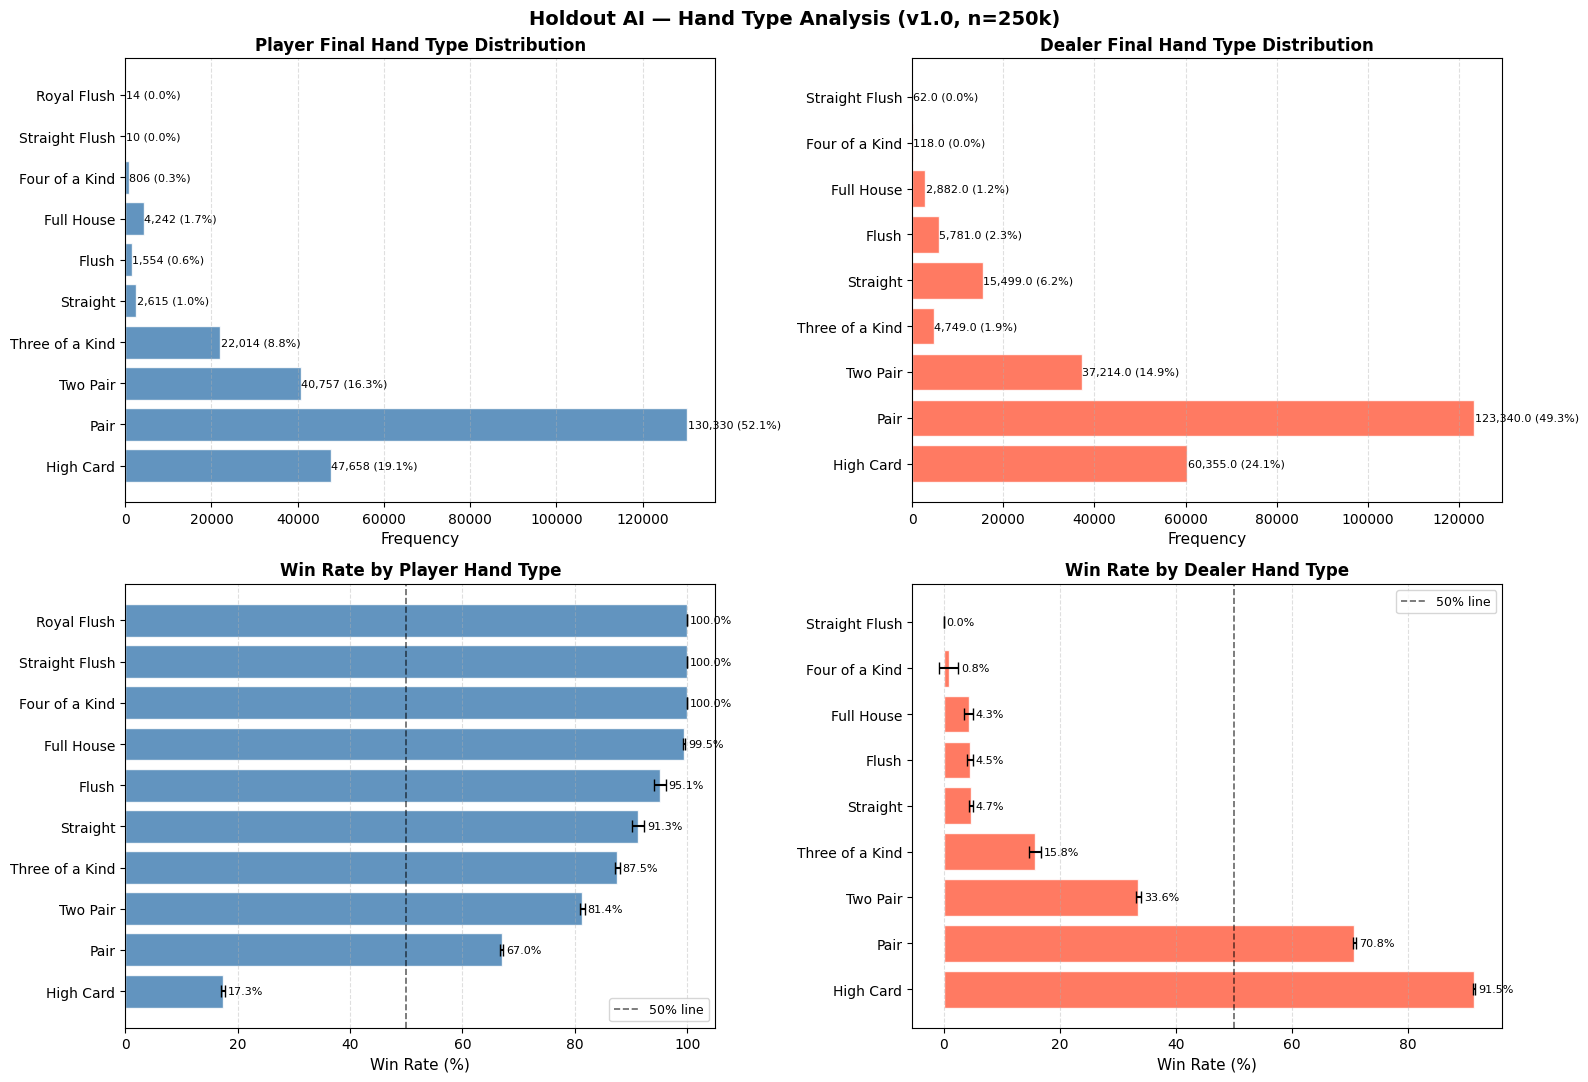


── Player hand type summary ──────────────────────────────────────────
                   Count Win Rate 95% CI
Player_Hand_Type                        
Royal Flush           14   100.0%  ±0.0%
Straight Flush        10   100.0%  ±0.0%
Four of a Kind       806   100.0%  ±0.0%
Full House          4242    99.5%  ±0.2%
Flush               1554    95.1%  ±1.1%
Straight            2615    91.3%  ±1.1%
Three of a Kind    22014    87.5%  ±0.4%
Two Pair           40757    81.4%  ±0.4%
Pair              130330    67.0%  ±0.3%
High Card          47658    17.3%  ±0.3%

── Dealer hand type summary ──────────────────────────────────────────
                     Count Win Rate 95% CI
Dealer_Hand_Type                          
Straight Flush        62.0     0.0%  ±0.0%
Four of a Kind       118.0     0.8%  ±1.7%
Full House          2882.0     4.3%  ±0.7%
Flush               5781.0     4.5%  ±0.5%
Straight           15499.0     4.7%  ±0.3%
Three of a Kind     4749.0    15.8%  ±1.0%
Two Pair           3

In [21]:
# ── Hand type analysis: frequencies and win rates by hand category ───────────

if 'v_1_0' not in dfs:
    print("v_1_0 CSV not loaded — check CSV_DIR path in the setup cell.")
else:
    df = dfs['v_1_0']

    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    fig.suptitle('Holdout AI — Hand Type Analysis (v1.0, n=250k)', fontsize=14, fontweight='bold')

    # ── 1. Player hand type frequency ────────────────────────────────────────
    ax = axes[0, 0]
    p_counts = df['Player_Hand_Type'].value_counts().reindex(HAND_ORDER).dropna()
    bars = ax.barh(p_counts.index[::-1], p_counts.values[::-1], color='steelblue', alpha=0.85, edgecolor='white')
    ax.set_xlabel('Frequency', fontsize=11)
    ax.set_title("Player Final Hand Type Distribution", fontsize=12, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4, axis='x')
    for bar, val in zip(bars, p_counts.values[::-1]):
        ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
                f'{val:,} ({val/len(df)*100:.1f}%)', va='center', fontsize=8)

    # ── 2. Dealer hand type frequency ────────────────────────────────────────
    ax = axes[0, 1]
    d_counts = df['Dealer_Hand_Type'].value_counts().reindex(HAND_ORDER).dropna()
    bars = ax.barh(d_counts.index[::-1], d_counts.values[::-1], color='tomato', alpha=0.85, edgecolor='white')
    ax.set_xlabel('Frequency', fontsize=11)
    ax.set_title("Dealer Final Hand Type Distribution", fontsize=12, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4, axis='x')
    for bar, val in zip(bars, d_counts.values[::-1]):
        ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
                f'{val:,} ({val/len(df)*100:.1f}%)', va='center', fontsize=8)

    # ── 3. Win rate by player hand type ──────────────────────────────────────
    ax = axes[1, 0]
    wr_by_player = (df.groupby('Player_Hand_Type')['Result']
                      .agg(['mean', 'count'])
                      .reindex(HAND_ORDER)
                      .dropna())
    wr_by_player['ci'] = 1.96 * np.sqrt(
        wr_by_player['mean'] * (1 - wr_by_player['mean']) / wr_by_player['count'])
    ax.barh(wr_by_player.index[::-1],
            wr_by_player['mean'].values[::-1] * 100,
            xerr=wr_by_player['ci'].values[::-1] * 100,
            color='steelblue', alpha=0.85, capsize=4,
            error_kw={'elinewidth':1.5}, edgecolor='white')
    ax.axvline(50, color='black', linestyle='--', linewidth=1.2, alpha=0.6, label='50% line')
    ax.set_xlabel('Win Rate (%)', fontsize=11)
    ax.set_title('Win Rate by Player Hand Type', fontsize=12, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4, axis='x')
    ax.legend(fontsize=9)
    for i, (wr, ci) in enumerate(zip(wr_by_player['mean'].values[::-1],
                                      wr_by_player['ci'].values[::-1])):
        ax.text(wr*100 + ci*100 + 0.5, i, f'{wr*100:.1f}%', va='center', fontsize=8)

    # ── 4. Win rate by dealer hand type ──────────────────────────────────────
    ax = axes[1, 1]
    wr_by_dealer = (df.groupby('Dealer_Hand_Type')['Result']
                      .agg(['mean', 'count'])
                      .reindex(HAND_ORDER)
                      .dropna())
    wr_by_dealer['ci'] = 1.96 * np.sqrt(
        wr_by_dealer['mean'] * (1 - wr_by_dealer['mean']) / wr_by_dealer['count'])
    ax.barh(wr_by_dealer.index[::-1],
            wr_by_dealer['mean'].values[::-1] * 100,
            xerr=wr_by_dealer['ci'].values[::-1] * 100,
            color='tomato', alpha=0.85, capsize=4,
            error_kw={'elinewidth':1.5}, edgecolor='white')
    ax.axvline(50, color='black', linestyle='--', linewidth=1.2, alpha=0.6, label='50% line')
    ax.set_xlabel('Win Rate (%)', fontsize=11)
    ax.set_title('Win Rate by Dealer Hand Type', fontsize=12, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4, axis='x')
    ax.legend(fontsize=9)
    for i, (wr, ci) in enumerate(zip(wr_by_dealer['mean'].values[::-1],
                                      wr_by_dealer['ci'].values[::-1])):
        ax.text(wr*100 + ci*100 + 0.5, i, f'{wr*100:.1f}%', va='center', fontsize=8)

    plt.tight_layout()
    plt.savefig('hand_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Summary table ─────────────────────────────────────────────────────────
    print("\n── Player hand type summary ──────────────────────────────────────────")
    summary = wr_by_player.copy()
    summary.columns = ['Win Rate', 'Count', '95% CI']
    summary['Win Rate'] = (summary['Win Rate'] * 100).round(1).astype(str) + '%'
    summary['95% CI']   = ('±' + (summary['95% CI'] * 100).round(1).astype(str) + '%')
    print(summary[['Count', 'Win Rate', '95% CI']].to_string())

    print("\n── Dealer hand type summary ──────────────────────────────────────────")
    summary_d = wr_by_dealer.copy()
    summary_d.columns = ['Win Rate', 'Count', '95% CI']
    summary_d['Win Rate'] = (summary_d['Win Rate'] * 100).round(1).astype(str) + '%'
    summary_d['95% CI']   = ('±' + (summary_d['95% CI'] * 100).round(1).astype(str) + '%')
    print(summary_d[['Count', 'Win Rate', '95% CI']].to_string())


## Runtime Analysis
Raw mean runtimes are heavily skewed by outliers — macOS scheduling interference, Numba JIT warmup on early games, and laptop sleep/wake cycles can inflate individual game times from ~50ms to minutes. This section analyzes the runtime distribution in detail and computes both raw and cleaned statistics using the IQR method (Q3 + 3×IQR as the upper fence).

── Runtime Summary (IQR outlier removal: Q3 + 3×IQR) ────────────────────
Version                  v_0_1       v_0_2       v_0_3          v_1_0
Games                   35,000      35,000      35,000        250,000
Median (ms)              950.5       889.8       655.4           49.4
Mean raw (ms)           1146.8       873.9       737.0          183.5
Mean clean (ms)          926.3       870.4       721.6           67.2
Std clean (ms)           133.0       117.4       250.3           55.0
p95 (ms)                1198.6      1010.7      1259.7          220.6
p99 (ms)                2550.7      1123.7      1490.2          365.9
Max (ms)              976423.0     40689.7    282746.6      1453073.1
Outliers         1,072 (3.06%)  77 (0.22%)  33 (0.09%)  6,009 (2.40%)
IQR fence (ms)          1511.9      1443.6      1804.1          284.3


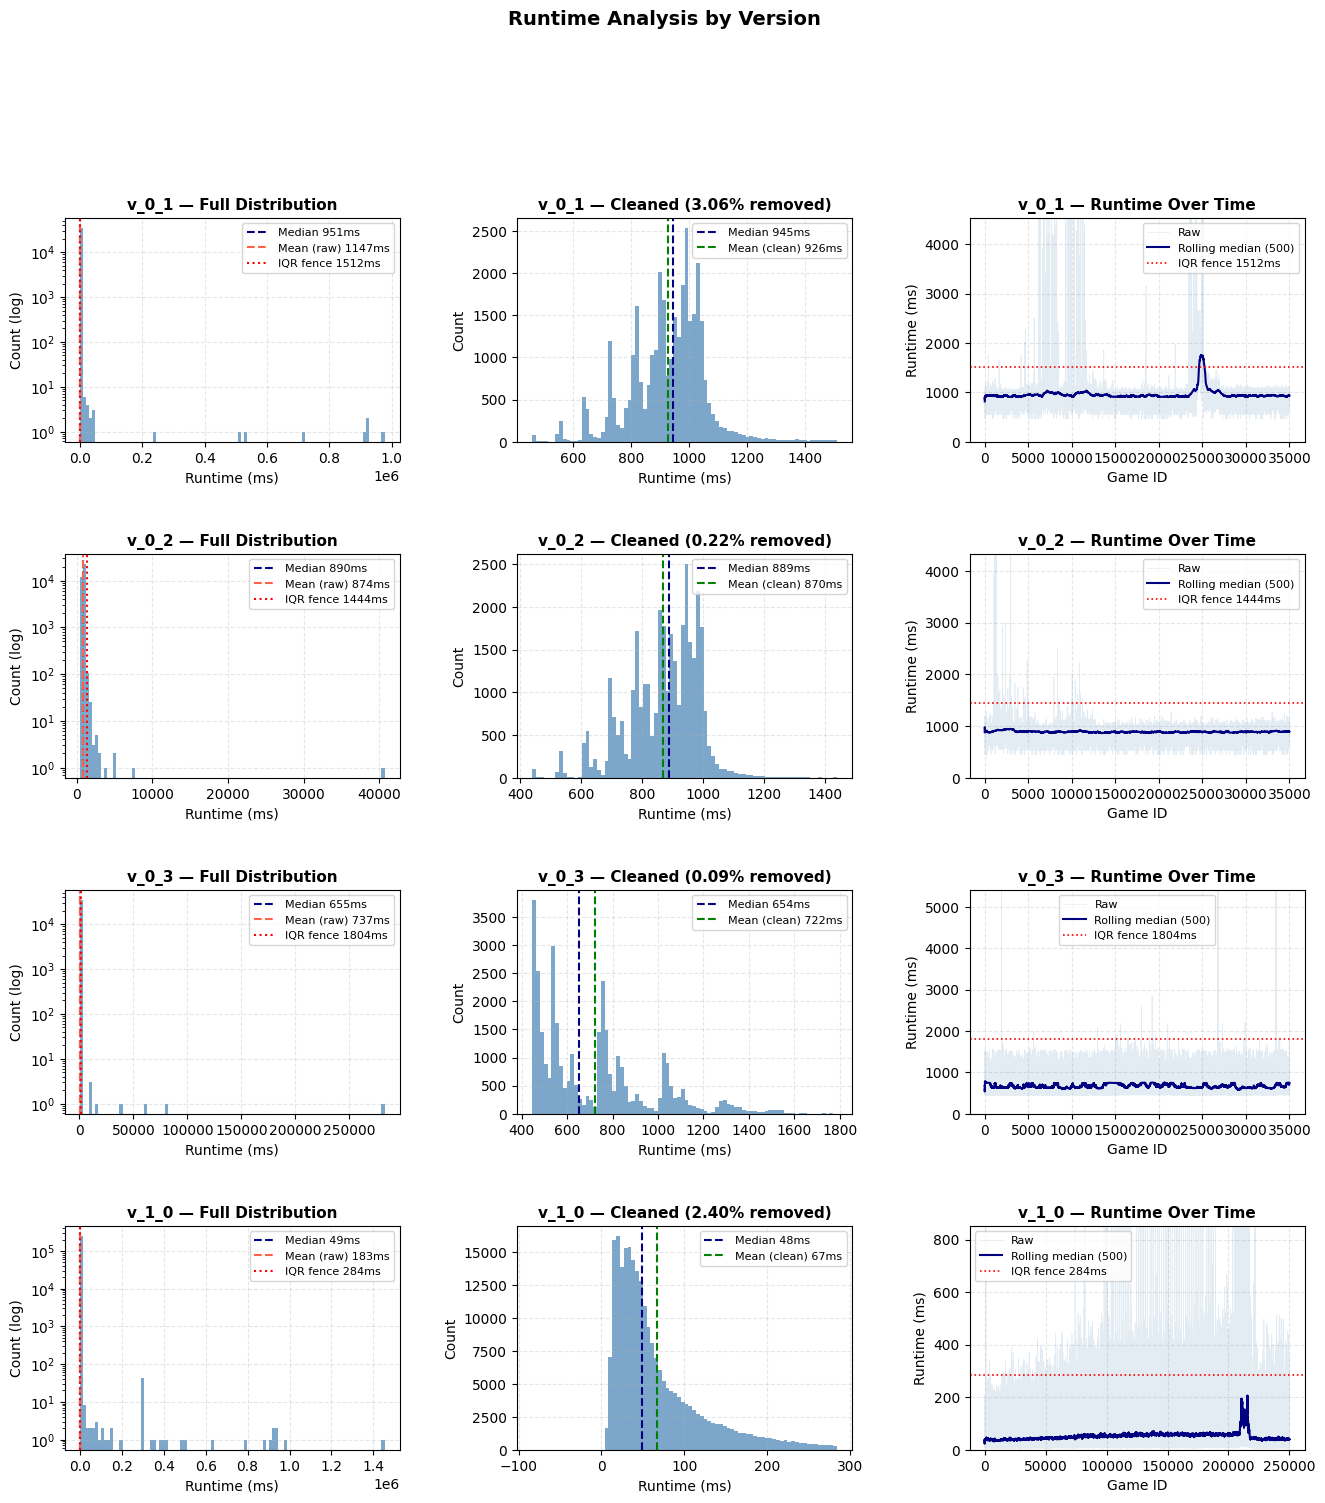


── Top 5 slowest games per version ─────────────────────────────────────

  v_0_1:
 Game_ID Time_Taken  Result  Player_Score  Dealer_Score
    9459 976423.0ms       1          6363          6679
    9755 924926.0ms       1          2697          5408
    9898 923991.0ms       0          2787          1096
    9951 911265.0ms       1          3377          7008
    6414 713574.0ms       1          2651          2877

  v_0_2:
 Game_ID Time_Taken  Result  Player_Score  Dealer_Score
    2989  40690.0ms       0          5601          4428
    1177   7401.0ms       1          2098          5759
    1187   5006.0ms       1          4351          5757
    1336   4964.0ms       1          3856          6102
    1068   3965.0ms       1          5149          6472

  v_0_3:
 Game_ID Time_Taken  Result  Player_Score  Dealer_Score
   26841 282747.0ms       1          4812          7091
   33388  80195.0ms       1          4077          5385
   26789  61621.0ms       1          3992          6555


In [22]:
# ── Runtime analysis with outlier detection ───────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

CSV_DIR = os.path.join(PROJECT_ROOT, 'backend', 'app', 'simulators', 'results')
CSV_FILES = {
    'v_0_1': 'v_0_1.csv',
    'v_0_2': 'v_0_2.csv',
    'v_0_3': 'v_0_3.csv',
    'v_1_0': 'v_1_0.csv',
}

def runtime_stats(rt_ms):
    """Compute raw and IQR-cleaned runtime statistics."""
    Q1, Q3 = rt_ms.quantile(0.25), rt_ms.quantile(0.75)
    IQR     = Q3 - Q1
    fence   = Q3 + 3 * IQR
    clean   = rt_ms[rt_ms <= fence]
    outliers= rt_ms[rt_ms > fence]
    return {
        'n':              len(rt_ms),
        'mean_raw':       rt_ms.mean(),
        'median':         rt_ms.median(),
        'std_raw':        rt_ms.std(),
        'p95':            rt_ms.quantile(0.95),
        'p99':            rt_ms.quantile(0.99),
        'max':            rt_ms.max(),
        'fence':          fence,
        'n_outliers':     len(outliers),
        'pct_outliers':   len(outliers) / len(rt_ms) * 100,
        'mean_clean':     clean.mean(),
        'median_clean':   clean.median(),
        'std_clean':      clean.std(),
        'clean':          clean,
        'outliers':       outliers,
    }

# ── Load and compute stats ────────────────────────────────────────────────────
dfs_rt = {}
stats_rows = []

for version, filename in CSV_FILES.items():
    path = os.path.join(CSV_DIR, filename)
    if not os.path.exists(path):
        print(f"✗ {version}: not found")
        continue
    df  = pd.read_csv(path)
    rt  = df['Time_Taken'] * 1000
    s   = runtime_stats(rt)
    dfs_rt[version] = (df, s)
    stats_rows.append({
        'Version':        version,
        'Games':          f"{s['n']:,}",
        'Median (ms)':    f"{s['median']:.1f}",
        'Mean raw (ms)':  f"{s['mean_raw']:.1f}",
        'Mean clean (ms)':f"{s['mean_clean']:.1f}",
        'Std clean (ms)': f"{s['std_clean']:.1f}",
        'p95 (ms)':       f"{s['p95']:.1f}",
        'p99 (ms)':       f"{s['p99']:.1f}",
        'Max (ms)':       f"{s['max']:.1f}",
        'Outliers':       f"{s['n_outliers']:,} ({s['pct_outliers']:.2f}%)",
        'IQR fence (ms)': f"{s['fence']:.1f}",
    })

print("── Runtime Summary (IQR outlier removal: Q3 + 3×IQR) ────────────────────")
summary_df = pd.DataFrame(stats_rows).set_index('Version')
print(summary_df.T.to_string())

# ── Visualizations ────────────────────────────────────────────────────────────
n_versions = len(dfs_rt)
fig = plt.figure(figsize=(16, 4 * n_versions))
gs  = gridspec.GridSpec(n_versions, 3, figure=fig, hspace=0.5, wspace=0.35)

for row, (version, (df, s)) in enumerate(dfs_rt.items()):
    rt = df['Time_Taken'] * 1000
    
    # ── Distribution (log scale, full range) ─────────────────────────────────
    ax = fig.add_subplot(gs[row, 0])
    ax.hist(rt, bins=100, color='steelblue', alpha=0.7, edgecolor='none')
    ax.axvline(s['median'],    color='navy',   linestyle='--', linewidth=1.5, label=f"Median {s['median']:.0f}ms")
    ax.axvline(s['mean_raw'],  color='tomato', linestyle='--', linewidth=1.5, label=f"Mean (raw) {s['mean_raw']:.0f}ms")
    ax.axvline(s['fence'],     color='red',    linestyle=':',  linewidth=1.5, label=f"IQR fence {s['fence']:.0f}ms")
    ax.set_yscale('log')
    ax.set_xlabel('Runtime (ms)', fontsize=10)
    ax.set_ylabel('Count (log)', fontsize=10)
    ax.set_title(f'{version} — Full Distribution', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.3)
    
    # ── Distribution (cleaned, zoomed in) ────────────────────────────────────
    ax = fig.add_subplot(gs[row, 1])
    ax.hist(s['clean'], bins=80, color='steelblue', alpha=0.7, edgecolor='none')
    ax.axvline(s['median_clean'], color='navy',   linestyle='--', linewidth=1.5, label=f"Median {s['median_clean']:.0f}ms")
    ax.axvline(s['mean_clean'],   color='green',  linestyle='--', linewidth=1.5, label=f"Mean (clean) {s['mean_clean']:.0f}ms")
    ax.set_xlabel('Runtime (ms)', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.set_title(f'{version} — Cleaned ({s["pct_outliers"]:.2f}% removed)', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.3)
    
    # ── Runtime over time (rolling median) ───────────────────────────────────
    ax = fig.add_subplot(gs[row, 2])
    rolling = rt.rolling(window=500, min_periods=1).median()
    ax.plot(df['Game_ID'], rt,      color='steelblue', alpha=0.15, linewidth=0.5, label='Raw')
    ax.plot(df['Game_ID'], rolling, color='navy',      linewidth=1.5,             label='Rolling median (500)')
    ax.axhline(s['fence'], color='red', linestyle=':', linewidth=1.2, label=f'IQR fence {s["fence"]:.0f}ms')
    ax.set_xlabel('Game ID', fontsize=10)
    ax.set_ylabel('Runtime (ms)', fontsize=10)
    ax.set_title(f'{version} — Runtime Over Time', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_ylim(0, min(s['fence'] * 3, rt.max()))

plt.suptitle('Runtime Analysis by Version', fontsize=14, fontweight='bold', y=1.01)
plt.savefig('runtime_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Outlier inspection ────────────────────────────────────────────────────────
print("\n── Top 5 slowest games per version ─────────────────────────────────────")
for version, (df, s) in dfs_rt.items():
    rt = df['Time_Taken'] * 1000
    top5 = df.nlargest(5, 'Time_Taken')[['Game_ID', 'Time_Taken', 'Result', 'Player_Score', 'Dealer_Score']].copy()
    top5['Time_Taken'] = (top5['Time_Taken'] * 1000).round(0).astype(str) + 'ms'
    print(f"\n  {version}:")
    print(top5.to_string(index=False))

The data confirms that the core execution complexity of your algorithms remains flat, predictable, and highly optimized across all simulation vectors; there is absolutely no internal algorithmic bottleneck, infinite loop, or state-bloat causing these massive runtime spikes. Instead, the sudden jumps from standard double-digit millisecond playtimes to multi-minute stalls are entirely artifacts of external OS-level power management and thread scheduling. Even when wrapping the execution shell in caffeinate -i, macOS aggressively prioritizes system-level thermal regulation, background indexing, and low-power core nap cycles when the machine sits idle or the display goes dark overnight.

## Machine Learning Explorations & Project Post-Mortem

While reinforcement learning (RL) or deep neural value estimators are heavily utilized in classic games like Heads-Up Texas Hold'em, a brief exploratory phase proved that standard model-free ML paths are fundamentally mismatched for the core design of Holdout.

### The Credit Assignment and Stochastic Variance Problem
Model convergence in Holdout faces two massive mathematical barriers:
1. **High Stochastic Variance**: The dealer's capacity to draw deep up to 8+ cards means an optimal player can make a sequence of text-book flawless decisions, yet suffer catastrophic losses simply because the dealer hits a 2% runner-runner sequence. This immense noise introduces blinding variance into temporal difference updates.
2. **The Credit Assignment Trap**: Because rewards are completely sparse and binary (issued only at the final showdown phase after a dozen cards have been processed), a traditional policy gradient network struggles intensely to isolate which specific early card decision directly triggered the loss. Was keeping that 8 of clubs on turn 2 the structural fault, or was it simply bad deck variance on turn 7?

### Conclusion
By choosing to treat this as an analytical software engineering challenge rather than an ML black-box problem, we successfully achieved near-optimal agent performance. Leveraging Numba JIT architectures, strict bit-packing arrays to achieve C-speed computations, and leveraging analytical LUT mappings to model the infinite-simulation limit, this engine provides a noise-free, high-speed solution capable of handling millions of games with absolute mathematical rigor.